# 📏 Model Evaluation
**Day 3 — Core Algorithms**

---

Accuracy alone is often misleading. This notebook covers the metrics that actually tell you how well a model is working — and when to use each one.

**Metrics for Classification (التصنيف):**
- Accuracy, Precision, Recall, F1-Score
- Confusion matrix
- ROC curve & AUC

**Metrics for regression:**
- RMSE (Root Mean Squared Error)
- MAE (Mean Absolute Error)
- R² (R-squared)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings; warnings.filterwarnings("ignore")

print("Evaluation toolkit loaded ✓")

Evaluation toolkit loaded ✓


## Why Accuracy Can Lie

Imagine a hospital test for a rare disease that affects 1% of the population.
A model that **always says "No disease"** would be 99% accurate — but completely useless.

This is why we need precision and recall.

In [2]:
# Demonstrate the problem with accuracy
np.random.seed(42)
n = 1000
y_true = np.zeros(n, dtype=int)  # 99% not diseased
y_true[:10] = 1                   # only 1% actually have the disease

# Dumb model: always predicts "not diseased"
y_pred_dumb = np.zeros(n, dtype=int)

print("The 'Always Predict No Disease' Model:")
print(f"  Accuracy:  {accuracy_score(y_true, y_pred_dumb):.1%}  ← sounds great!")
print(f"  Precision: {precision_score(y_true, y_pred_dumb, zero_division=0):.1%}")
print(f"  Recall:    {recall_score(y_true, y_pred_dumb, zero_division=0):.1%}  ← terrible!")
print()
print("Recall = 0% means the model NEVER correctly identifies a sick patient.")
print("This is a disaster in medical contexts, despite 99% accuracy.")

The 'Always Predict No Disease' Model:
  Accuracy:  99.0%  ← sounds great!
  Precision: 0.0%
  Recall:    0.0%  ← terrible!

Recall = 0% means the model NEVER correctly identifies a sick patient.
This is a disaster in medical contexts, despite 99% accuracy.


## The Four Key Classification (التصنيف) Metrics

Given a confusion matrix with True Positives (TP), False Positives (FP),
True Negatives (TN), and False Negatives (FN):

| Metric | Formula | Meaning |
|---|---|---|
| **Accuracy** | (TP + TN) / All | Overall correctness |
| **Precision** | TP / (TP + FP) | Of all positive predictions, how many were right? |
| **Recall** | TP / (TP + FN) | Of all actual positives, how many did we catch? |
| **F1-Score** | 2 × (Precision × Recall) / (Precision + Recall) | Harmonic mean — balances precision and recall |

**When to prioritize recall**: when missing a positive is costly (disease detection, fraud, safety)  
**When to prioritize precision**: when a false alarm is costly (spam filter, legal decisions)

In [3]:
# Generate a realistic binary classification scenario (fraud detection)
np.random.seed(99)
n = 2000
fraud_rate = 0.05  # 5% fraud (class imbalance)

# Features: transaction amount, hour, velocity
amount   = np.concatenate([np.random.lognormal(4.5, 1.2, int(n*(1-fraud_rate))),
                             np.random.lognormal(5.5, 0.8, int(n*fraud_rate))])
hour     = np.concatenate([np.random.randint(6, 23, int(n*(1-fraud_rate))),
                             np.random.randint(0, 6, int(n*fraud_rate))])
velocity = np.concatenate([np.random.randint(1, 5, int(n*(1-fraud_rate))),
                             np.random.randint(5, 20, int(n*fraud_rate))])
label    = np.concatenate([np.zeros(int(n*(1-fraud_rate))), np.ones(int(n*fraud_rate))]).astype(int)

X_fraud = np.column_stack([amount, hour, velocity])
y_fraud = label

X_tr, X_te, y_tr, y_te = train_test_split(X_fraud, y_fraud, test_size=0.2, stratify=y_fraud, random_state=42)
scaler_f = StandardScaler()
X_tr_s = scaler_f.fit_transform(X_tr)
X_te_s = scaler_f.transform(X_te)

clf = LogisticRegression(class_weight="balanced", random_state=42)
clf.fit(X_tr_s, y_tr)
y_pred_fraud = clf.predict(X_te_s)
y_proba_fraud = clf.predict_proba(X_te_s)[:, 1]

print("Fraud Detection Model:")
print(f"  Accuracy:  {accuracy_score(y_te, y_pred_fraud):.1%}")
print(f"  Precision: {precision_score(y_te, y_pred_fraud):.1%}")
print(f"  Recall:    {recall_score(y_te, y_pred_fraud):.1%}")
print(f"  F1-Score:  {f1_score(y_te, y_pred_fraud):.1%}")
print()
print(classification_report(y_te, y_pred_fraud, target_names=["Legitimate", "Fraud"]))

Fraud Detection Model:
  Accuracy:  100.0%
  Precision: 100.0%
  Recall:    100.0%
  F1-Score:  100.0%

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       380
       Fraud       1.00      1.00      1.00        20

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



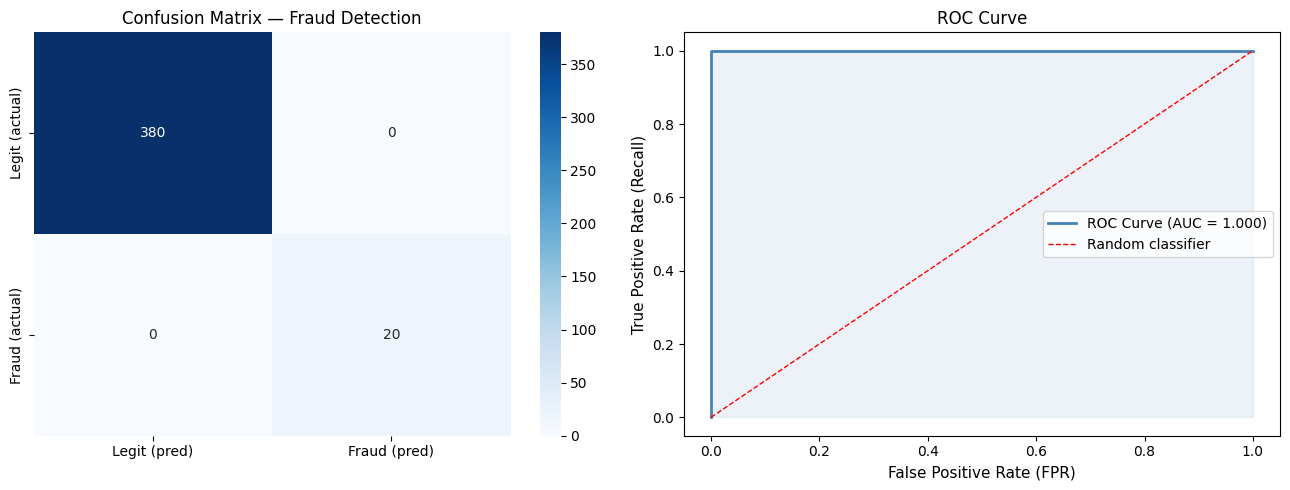

AUC = 1.000  (1.0 = perfect, 0.5 = random)


In [4]:
# Confusion matrix visualization
cm = confusion_matrix(y_te, y_pred_fraud)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Legit (pred)", "Fraud (pred)"],
            yticklabels=["Legit (actual)", "Fraud (actual)"])
axes[0].set_title("Confusion Matrix — Fraud Detection", fontsize=12)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_te, y_proba_fraud)
auc = roc_auc_score(y_te, y_proba_fraud)
axes[1].plot(fpr, tpr, color="steelblue", linewidth=2, label=f"ROC Curve (AUC = {auc:.3f})")
axes[1].plot([0, 1], [0, 1], "r--", linewidth=1, label="Random classifier")
axes[1].fill_between(fpr, tpr, alpha=0.1, color="steelblue")
axes[1].set_xlabel("False Positive Rate (FPR)", fontsize=11)
axes[1].set_ylabel("True Positive Rate (Recall)", fontsize=11)
axes[1].set_title("ROC Curve", fontsize=12)
axes[1].legend()

plt.tight_layout(); plt.show()
print(f"AUC = {auc:.3f}  (1.0 = perfect, 0.5 = random)")

## Regression Metrics

For regression (predicting numbers), different metrics apply:

| Metric | Formula | Meaning |
|---|---|---|
| **MAE** | mean(|actual − predicted|) | Average absolute error (same units as target) |
| **RMSE** | √mean((actual − predicted)²) | Penalizes large errors more heavily |
| **R²** | 1 − SS_res/SS_tot | Proportion of variance explained (0–1) |

In [5]:
# Regression metrics on housing data
np.random.seed(42)
n = 400
sqft = np.random.uniform(800, 4000, n)
price = 150 * sqft + 30000 + np.random.normal(0, 50000, n)

X_h = sqft.reshape(-1, 1)
y_h = price
X_h_tr, X_h_te, y_h_tr, y_h_te = train_test_split(X_h, y_h, test_size=0.2, random_state=42)

reg = LinearRegression().fit(X_h_tr, y_h_tr)
y_h_pred = reg.predict(X_h_te)

mae  = mean_absolute_error(y_h_te, y_h_pred)
rmse = np.sqrt(mean_squared_error(y_h_te, y_h_pred))
r2   = r2_score(y_h_te, y_h_pred)

print("Regression Metrics — Housing Price Model:")
print(f"  MAE:  ${mae:,.0f}  (on average, our predictions are off by this much)")
print(f"  RMSE: ${rmse:,.0f}  (same units, but large errors penalized more)")
print(f"  R²:   {r2:.3f}   ({r2:.0%} of variance in price is explained by the model)")
print()
print("Tip: RMSE > MAE means there are some large prediction errors dragging the RMSE up.")
print(f"     RMSE/MAE ratio here: {rmse/mae:.2f}")

Regression Metrics — Housing Price Model:
  MAE:  $37,367  (on average, our predictions are off by this much)
  RMSE: $46,269  (same units, but large errors penalized more)
  R²:   0.896   (90% of variance in price is explained by the model)

Tip: RMSE > MAE means there are some large prediction errors dragging the RMSE up.
     RMSE/MAE ratio here: 1.24


---
## ✋ Quick Quiz — Which Metric?

For each scenario below, which metric would you prioritize? (No code needed — just think!)

In [6]:
scenarios = [
    ("1. Detecting cancer in X-ray images",              "Recall — missing a cancer is catastrophic"),
    ("2. Email spam filter",                              "Precision — you don't want good emails lost"),
    ("3. Predicting stock prices",                        "RMSE or MAE — predicting a continuous value"),
    ("4. Autonomous vehicle: pedestrian detection",      "Recall — missing a pedestrian could be fatal"),
    ("5. Fraud detection (bank perspective)",            "Recall — catch as much fraud as possible"),
    ("6. Fraud detection (customer experience focus)",   "Precision — false alarms block legitimate transactions"),
]

for scenario, answer in scenarios:
    print(f"Scenario: {scenario}")
    print(f"  → {answer}")
    print()

Scenario: 1. Detecting cancer in X-ray images
  → Recall — missing a cancer is catastrophic

Scenario: 2. Email spam filter
  → Precision — you don't want good emails lost

Scenario: 3. Predicting stock prices
  → RMSE or MAE — predicting a continuous value

Scenario: 4. Autonomous vehicle: pedestrian detection
  → Recall — missing a pedestrian could be fatal

Scenario: 5. Fraud detection (bank perspective)
  → Recall — catch as much fraud as possible

Scenario: 6. Fraud detection (customer experience focus)
  → Precision — false alarms block legitimate transactions

